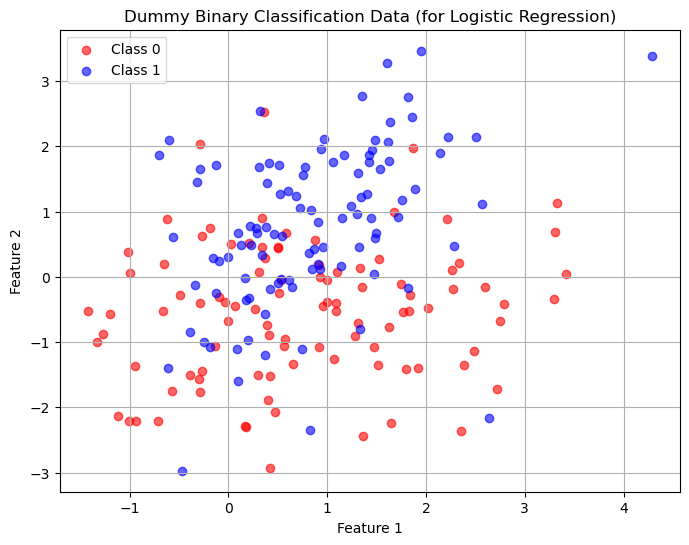

Features shape: (200, 2)
Target shape: (200,)


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

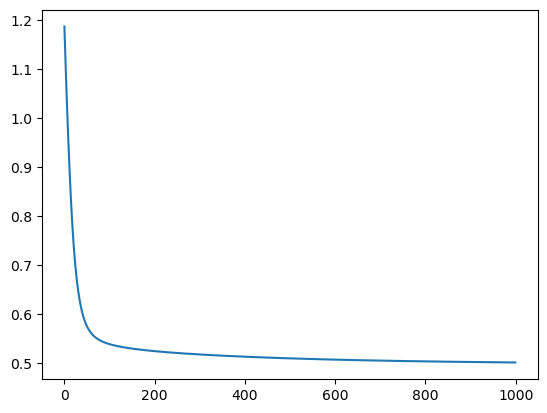

In [63]:
y_train = y.reshape(-1,1)

d = 5
m = x.shape[0]

w=np.random.randn(1,d*2)
b=np.array([0])


cost_history = []

alpha = 0.1
x_train = np.zeros((m, d*2))
k = 0

for i in range(1, d+1):
    x_train[:, k] = x[:, 0]**i
    k += 1
    x_train[:, k] = x[:, 1]**i
    k += 1
# x_train = np.zeros((m,d*2))
# k=0

# for i in range(1,d+1):
#     x_train[:,k] = x_train[:,0]**i
#     k=k+1
#     x_train[:,k] = x_train[:,1]**i
#     k=k+1

mean = np.mean(x_train,axis=0)
std = np.std(x_train,axis=0)
x_train = (x_train-mean)/(std+1e-10)

for i in range (1000):
    z = (x_train @ w.T) + b
    y_ = 1/(1+np.exp(-z))
    cost = np.mean(-(y_train * np.log(y_+0.000000001)) - ((1 - y_train) * np.log(1 - y_+0.000000001)))
    cost_history.append(cost)


    djdw =(x_train.T @ (y_ - y_train)).T / m
    djdb = np.sum(y_ - y_train) / m
    
    w = w - alpha * djdw
    b = b - alpha * djdb



x1 = x_train[:,0]
# x2 =(-w[0][0]*x1-b[0][0])/w[0][1]
# plt.plot(x1,x2)
# plt.show()

plt.plot(cost_history)
plt.show()                 

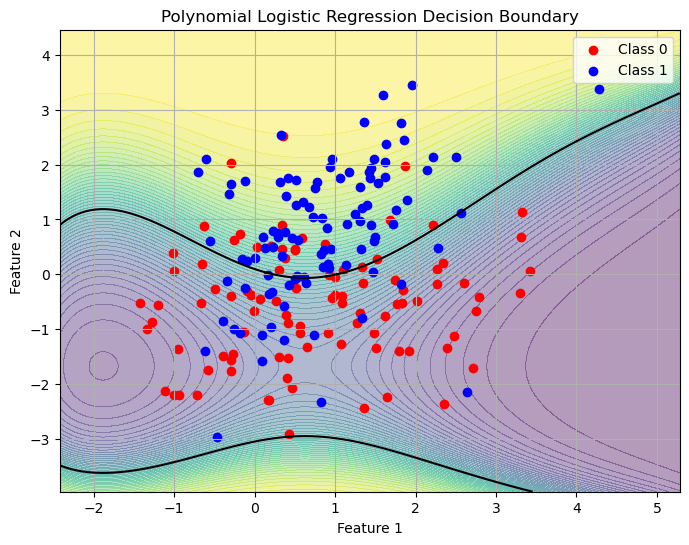

In [64]:
# Create grid points
x1_min, x1_max = x[:,0].min()-1, x[:,0].max()+1
x2_min, x2_max = x[:,1].min()-1, x[:,1].max()+1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

# Flatten grid
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

# Polynomial features for grid
grid_poly = np.zeros((grid_points.shape[0], d*2))

k = 0

for i in range(1, d+1):
    grid_poly[:,k] = grid_points[:,0]**i
    k += 1
    grid_poly[:,k] = grid_points[:,1]**i
    k += 1

# Normalize using training mean and std
grid_poly = (grid_poly - mean) / std

# Prediction
z = (grid_poly @ w.T) + b
pred = 1 / (1 + np.exp(-z))

# Reshape for contour
pred = pred.reshape(xx1.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))

plt.contourf(xx1, xx2, pred, levels=50, alpha=0.4)

plt.scatter(
    x[y==0][:,0],
    x[y==0][:,1],
    color="red",
    label="Class 0"
)

plt.scatter(
    x[y==1][:,0],
    x[y==1][:,1],
    color="blue",
    label="Class 1"
)

plt.contour(xx1, xx2, pred, levels=[0.5], colors='black')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()